# Author Info
---
Name: **Ejaz-ur-Rehman**\
Business Unit Head | Data Analyst | Lecturer (Accounting & Finance)\
MBA (Accounting & Finance), MS (Finance)\
Crystal Tech (Project of MUZHAB Group) | Al Ghazali University\
Karachi, Pakistan

![Date](https://img.shields.io/badge/Date-03--June--2026-green?logo=google-calendar)
[![Email](https://img.shields.io/badge/Email-ijazfinance%40gmail.com-blue?logo=gmail)](mailto:ijazfinance@gmail.com)
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Ejaz--ur--Rehman-blue?logo=linkedin)](https://www.linkedin.com/in/ejaz-ur-rehman/)
[![GitHub](https://img.shields.io/badge/GitHub-ejazurrehman-black?logo=github)](https://github.com/ejazurrehman)

# Project:
In this project, we're going to work with data from the Survey of Consumer Finances (SCF). The SCF is a survey sponsored by the US Federal Reserve. It tracks financial, demographic, and opinion information about families in the United States. The survey is conducted every three years, and we'll work with an extract of the results from 2022.

As you progress, you'll gain practical experience with key data science techniques, including:

- Preprocessing and analyzing survey-based financial datasets
- Applying k-means clustering to uncover meaningful household segments
- Reducing dimensionality using Principal Component Analysis (PCA)
- Creating and deploying an interactive Dash web application to visualize your findings
- By the end of the project, you'll have built a complete data pipeline—from clustering analysis to an interactive dashboard—that helps communicate insights about financially vulnerable households.

## About the Survey of Consumer Finances
From the US Federal Reserve website:

The Survey of Consumer Finances (SCF) is normally a triennial cross-sectional survey of U.S. families. The survey data include information on families’ balance sheets, pensions, income, and demographic characteristics. Information is also included from related surveys of pension providers and the earlier such surveys conducted by the Federal Reserve Board. No other study for the country collects comparable information. Data from the SCF are widely used, from analysis at the Federal Reserve and other branches of government to scholarly work at the major economic research centers.

# 1. Data Prepration

## 1.1 Importing Laibraries

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## 1.2 Read a CSV file into a DataFrame using pandas.
Including: Data Type, Shape and first five rows in the data.

### Task 1.1: Read the file "data/SCFP2022.csv" into the DataFrame df.

In [4]:
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Data Science\Islamic_FinTech\scfp2022excel.zip")
print("df type:", type(df))
print("df shape:", df.shape)
df.head()

df type: <class 'pandas.core.frame.DataFrame'>
df shape: (22975, 357)


,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
0,1,11,3027.956120,2,70,5,9,3,2,2,...,4,2,4,2,1,8,3,3,2,1
1,1,12,3054.900065,2,70,5,9,3,2,2,...,4,2,5,2,1,8,3,3,2,1
2,1,13,3163.637766,2,70,5,9,3,2,2,...,4,2,4,2,1,8,3,3,1,1
3,1,14,3166.228463,2,70,5,9,3,2,2,...,3,2,4,1,1,6,3,2,1,1
4,1,15,3235.624715,2,70,5,9,3,2,2,...,3,2,4,2,1,8,3,3,1,1


**NOTE**: One of the first things you might notice here is that this dataset is HUGE — over 22,000 rows and 357 columns! SO MUCH DATA!!! We won't have time to explore all of the features in this dataset, but you can look in the data dictionary for this project for details and links to the official Code Book. For now, let's just say that this dataset tracks all sorts of behaviors relating to the ways households earn, save, and spend money in the United States.

For this project, we're going to focus on households that have "been turned down for credit or feared being denied credit in the past 5 years." These households are identified in the "TURNFEAR" column.

### Task 1.2: Use a mask to subset create df to only households that have been turned down or feared being turned down for credit ("TURNFEAR" == 1). Assign this subset to the variable name df_fear.

In [5]:
# Create a boolean mask where the "TURNFEAR" column is equal to 1
# This will return a Series of boolean values (True/False) indicating whether each row meets the condition.
mask = df["TURNFEAR"] == 1
mask.head(10)

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
9    False
Name: TURNFEAR, dtype: bool

In [6]:
mask.sum()  # This will give us the count of rows where "TURNFEAR" is equal to 1

np.int64(3839)

In [7]:
# Display the column names of df_fear to check for the presence of "AGECL"
mask = df["TURNFEAR"] == 1
df_fear = df[mask]
print("df_fear type:", type(df_fear))
print("df_fear shape:", df_fear.shape)
df_fear.head()

df_fear type: <class 'pandas.core.frame.DataFrame'>
df_fear shape: (3839, 357)


,YY1,Y1,WGT,HHSEX,AGE,AGECL,EDUC,EDCL,MARRIED,KIDS,...,NWCAT,INCCAT,ASSETCAT,NINCCAT,NINC2CAT,NWPCTLECAT,INCPCTLECAT,NINCPCTLECAT,INCQRTCAT,NINCQRTCAT
20,5,51,7191.481109,2,19,1,8,2,1,0,...,1,3,1,2,1,2,5,4,2,2
21,5,52,7352.487205,2,19,1,8,2,1,0,...,1,3,1,2,1,2,5,4,2,2
22,5,53,7270.703541,2,19,1,8,2,1,0,...,1,3,1,3,1,2,5,5,2,2
23,5,54,7383.866597,2,19,1,8,2,1,0,...,1,3,1,3,1,2,5,5,2,2
24,5,55,7330.537669,2,19,1,8,2,1,0,...,1,3,1,2,1,2,5,4,2,2


# 2. Data Exploration
- Now that we have our subset, let's explore the characteristics of this group. One of the features is age group ("AGECL").

### Task 2.1: Create a list age_groups with the unique values in the "AGECL" column. Then review the entry for "AGECL" in the Code Book (https://sda.berkeley.edu/sdaweb/docs/scfcomb2019/DOC/hcbk.htm) to determine what the values represent.

In [8]:
# Display the column names of df_fear to check for the presence of "AGECL"
for col in df_fear.columns:
    print(repr(col))

'YY1'
'Y1'
'WGT'
'HHSEX'
'AGE'
'AGECL'
'EDUC'
'EDCL'
'MARRIED'
'KIDS'
'LF'
'LIFECL'
'FAMSTRUCT'
'RACECL'
'RACECL4'
'RACECL5'
'RACECL_EX'
'RACE'
'OCCAT1'
'OCCAT2'
'INDCAT'
'FOODHOME'
'FOODAWAY'
'FOODDELV'
'RENT'
'INCOME'
'WAGEINC'
'BUSSEFARMINC'
'INTDIVINC'
'KGINC'
'SSRETINC'
'TRANSFOTHINC'
'PENACCTWD'
'NORMINC'
'WSAVED'
'SAVED'
'SAVRES1'
'SAVRES2'
'SAVRES3'
'SAVRES4'
'SAVRES5'
'SAVRES6'
'SAVRES7'
'SAVRES8'
'SAVRES9'
'SPENDMOR'
'SPENDLESS'
'EXPENSHILO'
'LATE'
'LATE60'
'HPAYDAY'
'BNKRUPLAST5'
'KNOWL'
'YESFINRISK'
'NOFINRISK'
'CRDAPP'
'TURNDOWN'
'FEARDENIAL'
'TURNFEAR'
'FORECLLAST5'
'EMERGBORR'
'EMERGSAV'
'EMERGPSTP'
'EMERGCUT'
'EMERGWORK'
'HBORRFF'
'HBORRCC'
'HBORRALT'
'HBORRFIN'
'HSAVFIN'
'HSAVNFIN'
'HPSTPPAY'
'HPSTPLN'
'HPSTPOTH'
'HCUTFOOD'
'HCUTENT'
'HCUTOTH'
'FINLIT'
'BSHOPNONE'
'BSHOPGRDL'
'BSHOPMODR'
'ISHOPNONE'
'ISHOPGRDL'
'ISHOPMODR'
'BCALL'
'BMAGZNEWS'
'BMAILADTV'
'BINTERNET'
'BFRIENDWORK'
'BFINPRO'
'BSELF'
'BDONT'
'BOTHER'
'ICALL'
'IMAGZNEWS'
'IMAILADTV'
'IINTERNET'
'IFRIENDWOR

In [9]:
# Assuming "AGECL" is a column in df_fear, we can display its first few values as follows:
df_fear["AGECL"].head()

20    1
21    1
22    1
23    1
24    1
Name: AGECL, dtype: int64

In [10]:
# To find out how many unique values are in the "AGECL" column of df_fear, we can use the nunique() method:
df_fear["AGECL"].nunique()

6

In [11]:
age_groups = df_fear["AGECL"].nunique()
print("Age Groups:", age_groups)

Age Groups: 6


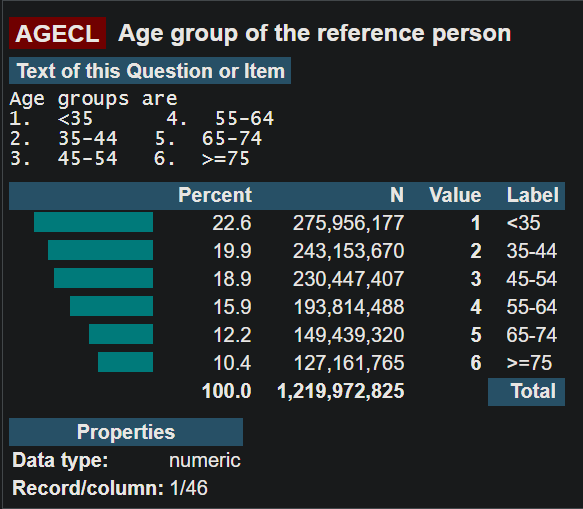

**NOTE:** Looking at the Code Book we can see that "AGECL" represents categorical data, even though the values in the column are numeric.
his simplifies data storage, but it's not very human-readable. So before we create a visualization, let's create a version of this column that uses the actual group names.

### Task 2.2: Create a Series agecl that contains the observations from "AGECL" using the true group names.

- Create a Series in pandas.
- Replace values in a column using pandas.

In [12]:
# Display the first 10 values of the "AGECL" column in df_fear
df_fear["AGECL"].head(10)

20     1
21     1
22     1
23     1
24     1
110    4
111    4
112    4
113    4
114    4
Name: AGECL, dtype: int64

In [13]:
# Create a dictionary to map the numeric values in "AGECL" to their corresponding age group labels.
agecl_dict = {
    1: "Under 35",
    2: "35-44",
    3: "45-54",
    4: "55-64",
    5: "65-74",
    6: "75 or Older",
}

# Use the replace() method to create a new Series with the numeric values in "AGECL" replaced by their corresponding age group labels.
age_cl = df_fear["AGECL"].replace(agecl_dict)
print("age_cl type:", type(age_cl))
print("age_cl shape:", age_cl.shape)
age_cl.head()

age_cl type: <class 'pandas.core.series.Series'>
age_cl shape: (3839,)


20    Under 35
21    Under 35
22    Under 35
23    Under 35
24    Under 35
Name: AGECL, dtype: object

### Task 2.3: Create a bar chart showing the value counts from age_cl. Be sure to label the x-axis "Age Group", the y-axis "Frequency (count)", and use the title "Credit Fearful: Age Groups".

- Create a bar chart using pandas.

In [14]:
# Display the first few values of the age_cl Series to verify that the numeric values have been replaced with the corresponding age group labels.
age_cl.head()

20    Under 35
21    Under 35
22    Under 35
23    Under 35
24    Under 35
Name: AGECL, dtype: object

In [15]:
# To find out how many times each age group appears in the age_cl Series, we can use the value_counts() method:
age_cl.value_counts()

AGECL
35-44          936
Under 35       917
45-54          802
55-64          682
65-74          398
75 or Older    104
Name: count, dtype: int64

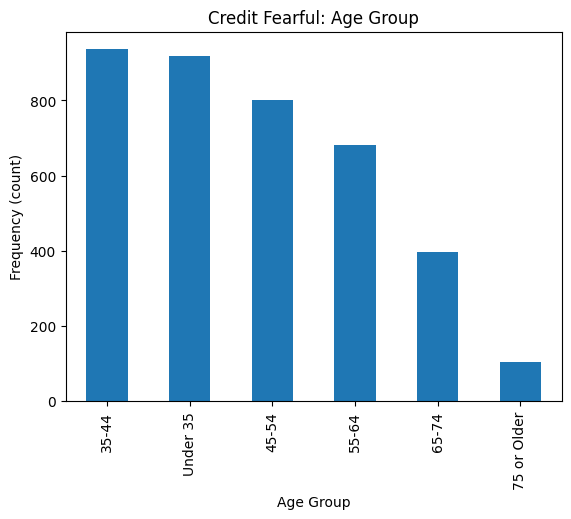

In [16]:
# Store the result of age_cl.value_counts() in a variable for later use in plotting.
age_cl_value_counts = age_cl.value_counts()

# Bar plot of `age_cl_value_counts`
age_cl_value_counts.plot(
    kind = "bar",
    xlabel = "Age Group",
    ylabel = "Frequency (count)",
    title = "Credit Fearful: Age Group"
);

Interpretation: Credit Fearful: Age Group
- The chart shows that credit fear is most common among younger and middle-aged individuals. Respondents under 35 and those aged 35–44 have the highest frequencies of credit fear, with counts exceeding 900. The frequency gradually declines with age, falling to around 400 for the 65–74 group and just over 100 for those 75 or older. This suggests that younger adults are more likely to avoid applying for credit due to fear of rejection, while older individuals exhibit lower levels of credit fear.

### Task 2.4: Create a histogram of the "AGE" column with 10 bins. Be sure to label the x-axis "Age", the y-axis "Frequency (count)", and use the title "Credit Fearful: Age Distribution".

- Create a histogram using pandas.

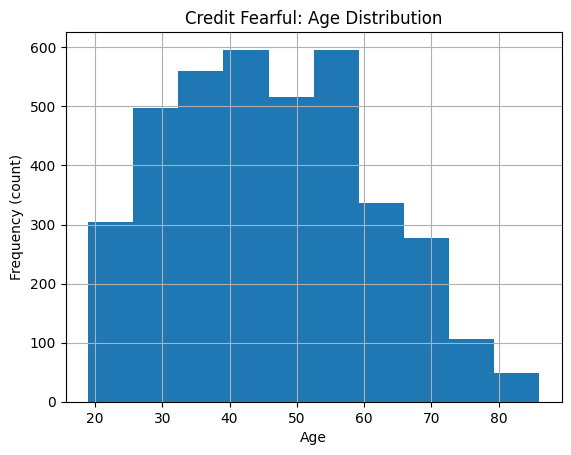

In [17]:
# Plot histogram of "AGE"
df_fear["AGE"].hist(bins=10)
plt.xlabel("Age")
plt.ylabel("Frequency (count)")
plt.title("Credit Fearful: Age Distribution");

Interpretation: Credit Fearful Age Distribution

The histogram illustrates the age distribution of respondents who reported being credit fearful, meaning they avoided applying for credit due to concerns about being denied.

Key observations include:

- The distribution is concentrated between 30 and 60 years of age, indicating that credit fear is most prevalent among working-age adults.
- The highest frequencies occur in the 40–60 age range, suggesting that middle-aged individuals are the most likely to exhibit credit fear.
- The number of credit-fearful respondents declines after age 60 and drops sharply among those aged 75 and above.
- Younger adults (below 30) are represented but in smaller numbers compared to middle-aged groups.

Overall, the results suggest that credit fear is primarily a concern among economically active individuals in their middle years, possibly due to greater reliance on credit for housing, education, business activities, and household expenses. In contrast, older individuals may have less need for new credit or may have established financial stability, resulting in lower levels of credit fear.

### Task 2.5: Create a horizontal bar chart showing the normalized value counts for "RACE". In our chart, we should replace the numerical values with the true group names. Be sure to label the x-axis "Frequency (%)", the y-axis "Race", and use the title "Credit Fearful: Racial Groups". Finally, set the xlim for this plot to (0,1).

- Create a bar chart using pandas.

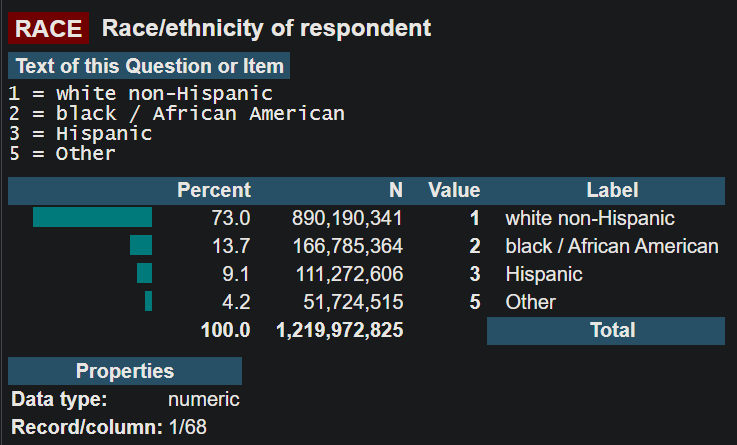

In [18]:
race_dict = {
    1: "White/Non-Hispanic",
    2: "Black/African-American",
    3: "Hispanic",
    5: "Other",
}

In [19]:
race = df_fear["RACE"].replace(race_dict)
race.head(10)

20     Black/African-American
21     Black/African-American
22     Black/African-American
23     Black/African-American
24     Black/African-American
110        White/Non-Hispanic
111        White/Non-Hispanic
112        White/Non-Hispanic
113        White/Non-Hispanic
114        White/Non-Hispanic
Name: RACE, dtype: object

In [20]:
race_value_counts = race.value_counts(normalize=True)
race_value_counts

RACE
White/Non-Hispanic        0.386559
Black/African-American    0.337327
Hispanic                  0.206043
4                         0.050274
Other                     0.019797
Name: proportion, dtype: float64

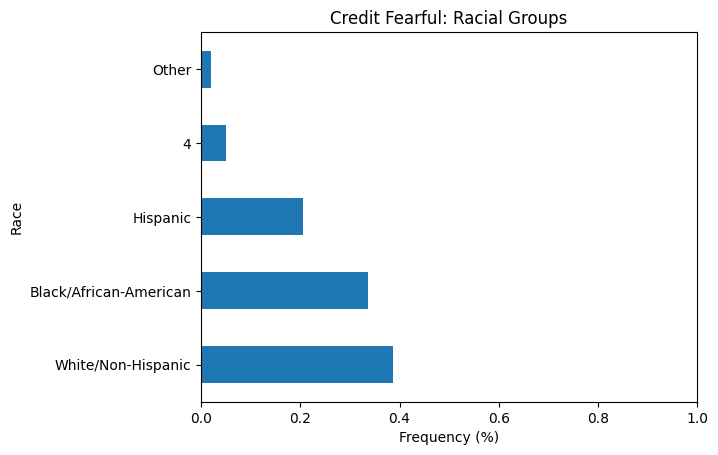

In [21]:
# Create bar chart of race_value_counts
race_value_counts.plot(kind="barh")
plt.xlim((0, 1))
plt.xlabel("Frequency (%)")
plt.ylabel("Race")
plt.title("Credit Fearful: Racial Groups");

**Interpretation:** Credit Fearful by Racial Group

The chart presents the distribution of credit-fearful respondents across racial groups. The results indicate that White/Non-Hispanic individuals account for the largest share of credit-fearful respondents (approximately 39%), followed by Black/African-American respondents (around 34%). Hispanic respondents represent about 21%, while the remaining racial groups constitute only a small proportion of the total sample.

**Key observations:**

- White/Non-Hispanic respondents make up the largest segment of credit-fearful individuals.
- Black/African-American respondents also represent a substantial share, only slightly lower than White respondents.
- Hispanic respondents account for a meaningful but smaller proportion.
- Other racial groups collectively contribute a relatively minor share of credit-fearful respondents.

**Important Note:**

These percentages represent the composition of the credit-fearful population, not the likelihood of being credit fearful within each racial group. To determine which racial group is more likely to experience credit fear, the analysis should compare the number of credit-fearful individuals to the total number of respondents within each racial category (i.e., calculate within-group credit fear rates). Therefore, the chart shows the distribution of credit-fearful respondents across racial groups rather than evidence that any particular racial group is inherently more or less credit fearful.

### Task 2.6: Recreate the horizontal bar chart we just made, but this time use the entire dataset df instead of the subset df_fear. The title of this plot should be "SCF Respondents: Racial Groups"

- Create a bar chart using pandas.

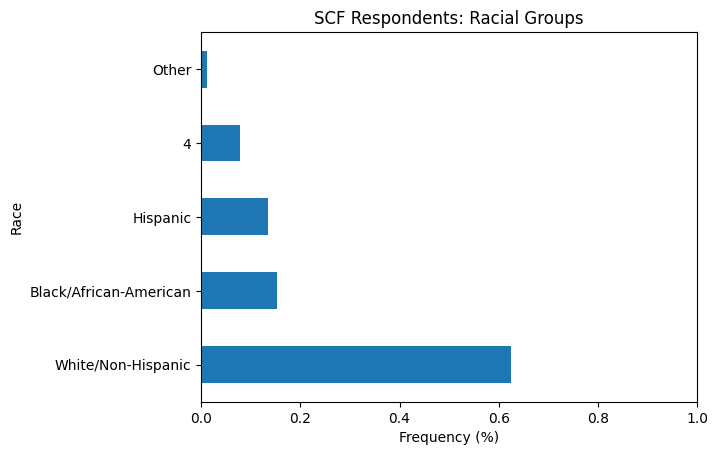

In [22]:
# Now let's do the same for the entire df dataset to compare the racial distribution of credit fearful respondents to the overall distribution in the survey.
race = df["RACE"].replace(race_dict)
race_value_counts = race.value_counts(normalize=True)
# Create bar chart of race_value_counts
race_value_counts.plot(kind="barh")
plt.xlim((0, 1))
plt.xlabel("Frequency (%)")
plt.ylabel("Race")
plt.title("SCF Respondents: Racial Groups");

**Interpretation:** SCF Respondents by Racial Group

The chart illustrates the racial composition of respondents in the Survey of Consumer Finances (SCF) sample. White/Non-Hispanic respondents constitute the majority of the sample, accounting for approximately 62% of all respondents. Black/African-American respondents represent about 15%, while Hispanic respondents account for roughly 14%. The remaining racial categories make up a relatively small proportion of the sample.

**Key observations:**
- White/Non-Hispanic respondents dominate the sample, representing nearly two-thirds of all participants.
- Black/African-American and Hispanic respondents have similar levels of representation, each comprising around one-sixth of the sample.
- Other racial groups contribute only a small share of the total respondents.
- The sample reflects substantial racial diversity, although representation is not evenly distributed across groups.

**Comparison with the Credit-Fearful Sample**
- When compared with the previous chart showing credit-fearful respondents:
  - White/Non-Hispanic individuals account for 62% of the overall sample but only about 39% of the credit-fearful group.
  - Black/African-American respondents represent 15% of the overall sample but approximately 34% of the credit-fearful group.
  - Hispanic respondents represent 14% of the overall sample but about 21% of the credit-fearful group.

This comparison suggests that Black/African-American and Hispanic respondents appear disproportionately represented among credit-fearful individuals relative to their share of the overall sample, whereas White/Non-Hispanic respondents appear underrepresented. However, a formal conclusion requires calculating the credit fear rate within each racial group and conducting statistical tests to determine whether the observed differences are significant.

**Research Interpretation:**
The descriptive evidence indicates that credit fear may not be distributed uniformly across racial groups. Minority groups, particularly Black/African-American and Hispanic respondents, appear more likely to be represented among individuals who avoid applying for credit due to fear of rejection. This pattern may reflect differences in access to credit, previous credit experiences, financial vulnerability, or perceptions of lending institutions, which can be examined further through inferential statistical analysis.

### Task 2.7: Create a DataFrame df_inccat that shows the normalized frequency for income categories for both the credit fearful and non-credit fearful households in the dataset. 

- Aggregate data in a Series using value_counts in pandas.
- Aggregate data using the groupby method in pandas.
- Create a Series in pandas.
- Rename a Series in pandas.
- Replace values in a column using pandas.
- Set and reset the index of a DataFrame in pandas.

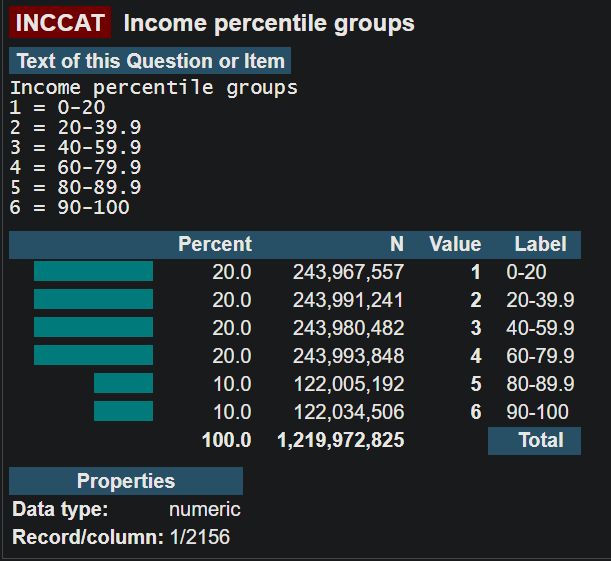

In [23]:
# Create a dictionary to map the numeric values in "INCCAT" to their corresponding income category labels.
inccat_dict = {
    1: "0-20",
    2: "21-39.9",
    3: "40-59.9",
    4: "60-79.9",
    5: "80-89.9",
    6: "90-100",
}

# Use the replace() method to create a new Series with the numeric values in "INCCAT" replaced by their corresponding income category labels, and then group by "TURNFEAR" and calculate the frequency of each income category within each group.
df_inccat = (
    df["INCCAT"].replace(inccat_dict)
    # Group the "INCCAT" values by the "TURNFEAR" column and calculate the frequency of each income category within each group.
    .groupby(df["TURNFEAR"]) 
    .value_counts(normalize=True) 
    .rename("Frequency") # Rename the resulting Series to "Frequency" for clarity.
    .to_frame() # Convert the Series to a DataFrame for easier manipulation and visualization.
    .reset_index() # Reset the index to turn the groupby keys into columns for easier plotting.
)


print("df_inccat type:", type(df_inccat)) # This will show us the type of df_inccat, which should be a DataFrame.
print("df_inccat shape:", df_inccat.shape) # This will show us the shape of df_inccat, which should indicate the number of rows and columns in the DataFrame.
df_inccat

df_inccat type: <class 'pandas.core.frame.DataFrame'>
df_inccat shape: (12, 3)


,TURNFEAR,INCCAT,Frequency
0,0,90-100,0.303982
1,0,60-79.9,0.162312
2,0,40-59.9,0.144492
3,0,0-20,0.140050
4,0,21-39.9,0.139162
5,0,80-89.9,0.110002
6,1,0-20,0.340714
7,1,21-39.9,0.266476
8,1,40-59.9,0.205001
9,1,60-79.9,0.112529


### Task 2.8: Using seaborn, create a side-by-side bar chart of df_inccat. Set hue to "TURNFEAR", and make sure that the income categories are in the correct order along the x-axis. Label to the x-axis "Income Category", the y-axis "Frequency (%)", and use the title "Income Distribution: Credit Fearful vs. Non-fearful".

- Create a bar chart using seaborn.

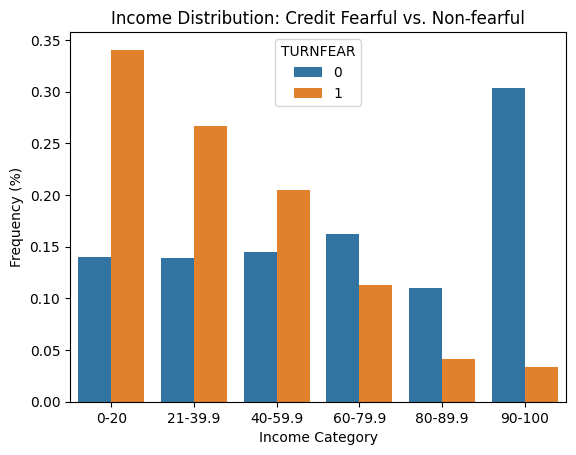

In [24]:
# Create bar chart of `df_inccat`
sns.barplot(
    x="INCCAT",
    y="Frequency",
    hue="TURNFEAR",
    data=df_inccat,
    order=inccat_dict.values()
)
plt.xlabel("Income Category")
plt.ylabel("Frequency (%)")
plt.title("Income Distribution: Credit Fearful vs. Non-fearful");

**Interpretation:** Income Distribution of Credit-Fearful vs. Non-Fearful Households

The chart compares the income distribution of respondents who are credit fearful (TURNFEAR = 1) and those who are not credit fearful (TURNFEAR = 0).

**Key Findings:**
- Credit-fearful respondents are concentrated in lower-income categories.
- Approximately 34% of credit-fearful individuals fall in the 0–20 income category.
- Nearly 61% of credit-fearful respondents are concentrated in the two lowest income groups (0–20 and 21–39.9).
- As income increases, the proportion of credit-fearful respondents declines steadily.
- Only about 4% of credit-fearful individuals are in the 80–89.9 income category.
- Around 3% belong to the 90–100 income category.
- Non-fearful respondents are more concentrated in higher-income categories.
- The largest share of non-fearful individuals (approximately 30%) falls within the 90–100 income category.
- Their distribution becomes increasingly concentrated in middle- and high-income groups.

**Overall Interpretation:**

The results indicate a strong negative relationship between income and credit fear. Individuals in lower-income households are substantially more likely to avoid applying for credit because they fear rejection, while higher-income households are much less likely to exhibit credit fear. This pattern may reflect differences in financial stability, creditworthiness, access to financial resources, and confidence in obtaining credit approval.

**Research Implication:**

The findings suggest that income is an important determinant of credit fear. Lower-income households may perceive a higher risk of loan denial or face greater financial constraints, leading them to self-select out of the credit market. Consequently, credit fear appears to be concentrated among economically vulnerable households, while higher-income households demonstrate greater confidence in accessing credit.

### Task 2.9: Calculate the correlation coefficient for "ASSET" and "HOUSES" in the whole dataset df.

- Calculate the correlation coefficient for two Series using pandas.

In [25]:
# Calculate the correlation between "ASSET" and "HOUSES" columns in the df DataFrame.
asset_house_corr = df["ASSET"].corr(df["HOUSES"])
print("SCF: Asset Houses Correlation:", asset_house_corr)

SCF: Asset Houses Correlation: 0.5617763110086196


**Interpretation:**

- The Pearson correlation coefficient between total household assets and housing assets is 0.562, indicating a moderate positive association. This suggests that households with higher-valued housing assets generally possess greater overall wealth. However, the correlation is not sufficiently strong to imply that housing wealth alone explains household asset accumulation, highlighting the importance of other financial and non-financial assets in determining total household wealth.

### Task 2.10: Calculate the correlation coefficient for "ASSET" and "HOUSES" in the whole credit-fearful subset df_fear.

- Calculate the correlation coefficient for two Series using pandas.

In [26]:
# Calculate the correlation between "ASSET" and "HOUSES" columns in the df_fear DataFrame.
asset_house_corr = df_fear["ASSET"].corr(df_fear["HOUSES"])
print("Credit Fearful: Asset Houses Correlation:", asset_house_corr)

Credit Fearful: Asset Houses Correlation: 0.3649483861558831


**Interpretation:**

- The Pearson correlation coefficient between total assets and housing assets among credit-fearful households is 0.365, indicating a weak-to-moderate positive association. Although households with greater housing wealth tend to possess higher overall assets, the relationship is substantially weaker than that observed in the full SCF sample (r = 0.562). This suggests that housing wealth plays a less prominent role in explaining overall wealth accumulation among credit-fearful households, reflecting potentially lower levels of financial security, reduced access to credit, and less diversified asset holdings.

### Task 2.11: Make a correlation matrix using df, considering only the columns "ASSET", "HOUSES", "INCOME", "DEBT", and "EDUC".

- Create a correlation matrix in pandas.

In [27]:
# Create a new DataFrame `corr` that contains only the columns "ASSET", "HOUSES", "INCOME", "DEBT", and "EDUC" from the original DataFrame `df`.
cols = ["ASSET", "HOUSES", "INCOME", "DEBT", "EDUC"]
corr = df[cols]
corr.head()

,ASSET,HOUSES,INCOME,DEBT,EDUC
0,957100.0,674000,38804.734469,195000,9
1,1067300.0,858000,38264.278557,213000,9
2,957200.0,757000,36102.454910,279000,9
3,828600.0,710000,33508.266533,549000,9
4,825600.0,765000,35561.998998,223000,9


In [28]:
# Create a new DataFrame `corr` that contains only the columns "ASSET", "HOUSES", "INCOME", "DEBT", and "EDUC" from the original DataFrame `df`.
cols = ["ASSET", "HOUSES", "INCOME", "DEBT", "EDUC"]
corr = df[cols].corr()
corr

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.561776,0.706685,0.307137,0.120137
HOUSES,0.561776,1.000000,0.384699,0.251876,0.186120
INCOME,0.706685,0.384699,1.000000,0.306534,0.096549
DEBT,0.307137,0.251876,0.306534,1.000000,0.086561
EDUC,0.120137,0.186120,0.096549,0.086561,1.000000


In [29]:
cols = ["ASSET", "HOUSES", "INCOME", "DEBT", "EDUC"]
corr = df[cols].corr()
corr.style.background_gradient(axis=None)

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.561776,0.706685,0.307137,0.120137
HOUSES,0.561776,1.000000,0.384699,0.251876,0.186120
INCOME,0.706685,0.384699,1.000000,0.306534,0.096549
DEBT,0.307137,0.251876,0.306534,1.000000,0.086561
EDUC,0.120137,0.186120,0.096549,0.086561,1.000000


**Interpretation:**
- The correlation analysis reveals that household assets are most strongly associated with income (r = 0.707), followed by housing wealth (r = 0.562). Debt exhibits moderate positive relationships with both assets (r = 0.307) and income (r = 0.307), indicating that financially stronger households often maintain higher levels of borrowing. Education demonstrates weak correlations with all financial variables, suggesting that its influence on household financial outcomes may be indirect rather than immediate. Overall, the findings highlight income and housing wealth as the primary correlates of household asset accumulation in the SCF sample.

### Task 2.12: Make a correlation matrix using df_fear.

- Create a correlation matrix in pandas.

In [30]:
corr = df_fear[cols].corr()
corr.style.background_gradient(axis=None)

,ASSET,HOUSES,INCOME,DEBT,EDUC
ASSET,1.000000,0.364948,0.893282,0.477171,0.110655
HOUSES,0.364948,1.000000,0.314501,0.676984,0.195174
INCOME,0.893282,0.314501,1.000000,0.456622,0.108845
DEBT,0.477171,0.676984,0.456622,1.000000,0.182570
EDUC,0.110655,0.195174,0.108845,0.182570,1.000000


**Interpretation:**

- The correlation analysis for credit-fearful households reveals that income is the dominant correlate of wealth accumulation (r = 0.893), substantially stronger than in the overall SCF sample. Housing wealth exhibits a strong positive association with debt (r = 0.677), suggesting that homeownership within this group is closely tied to borrowing. In contrast, the relationship between housing wealth and total assets is relatively modest (r = 0.365), indicating that housing contributes less to overall wealth accumulation among credit-fearful households. These findings suggest that credit-fearful households rely more heavily on earned income and debt-financed assets, reflecting greater financial vulnerability and a weaker wealth base compared with the broader population.

### Task 2.13: Create a DataFrame df_educ that shows the normalized frequency for education categories for both the credit fearful and non-credit fearful households in the dataset. This will be similar in format to df_inccat, but focus on education. Note that we don't need to replace the numerical values in "EDUC" with the true labels.

- Aggregate data in a Series using value_counts in pandas.
- Aggregate data using the groupby method in pandas.
- Create a Series in pandas.
- Rename a Series in pandas.
- Replace values in a column using pandas.
- Set and reset the index of a DataFrame in pandas.

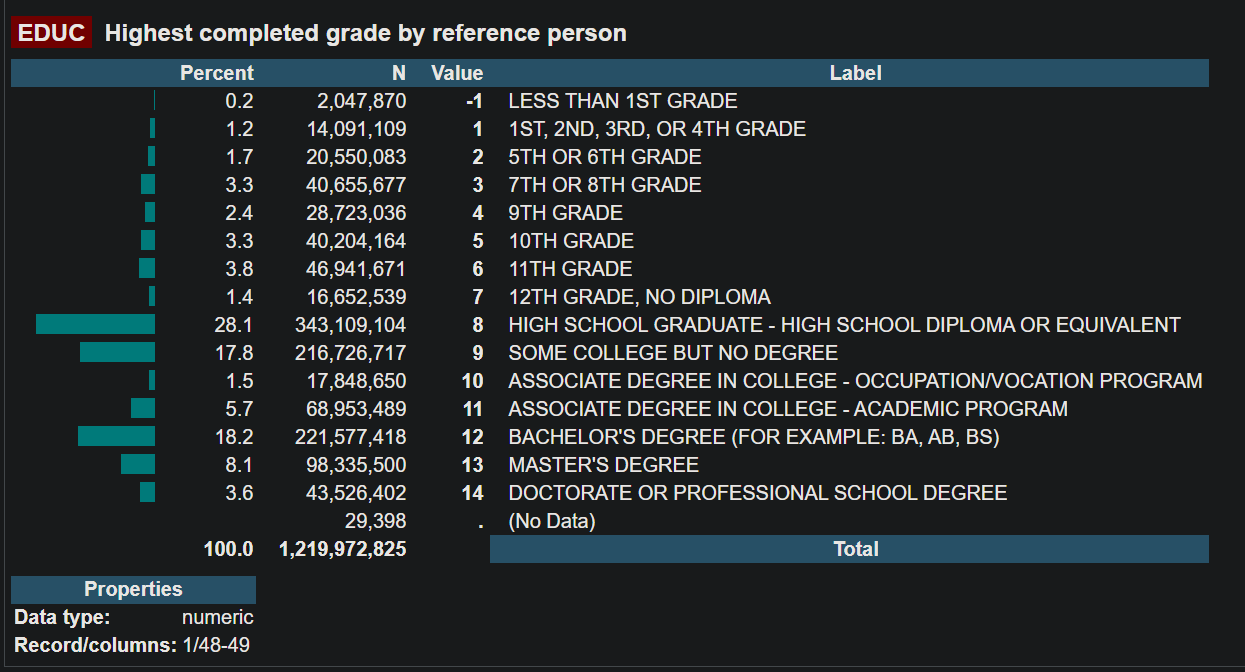

In [31]:
df_educ = (
    df["EDUC"]
)
df_educ.head()


0    9
1    9
2    9
3    9
4    9
Name: EDUC, dtype: int64

In [32]:
# Use the replace() method to create a new Series with the numeric values in "EDUC" replaced by their corresponding education level labels, and then group by "TURNFEAR" and calculate the frequency of each education level within each group.
df_educ = (
    df["EDUC"]
    .groupby(df["TURNFEAR"])
    .value_counts(normalize=True)
    .rename("Frequency")
    .to_frame()
    .reset_index()
)
df_educ.head()

,TURNFEAR,EDUC,Frequency
0,0,12,0.278689
1,0,8,0.174383
2,0,13,0.158967
3,0,9,0.111727
4,0,14,0.108539


### Task 2.14: Using seaborn, create a side-by-side bar chart of df_educ. Set hue to "TURNFEAR", and make sure that the education categories are in the correct order along the x-axis. Label to the x-axis "Education Level", the y-axis "Frequency (%)", and use the title "Educational Attainment: Credit Fearful vs. Non-fearful".

- Create a bar chart using seaborn.

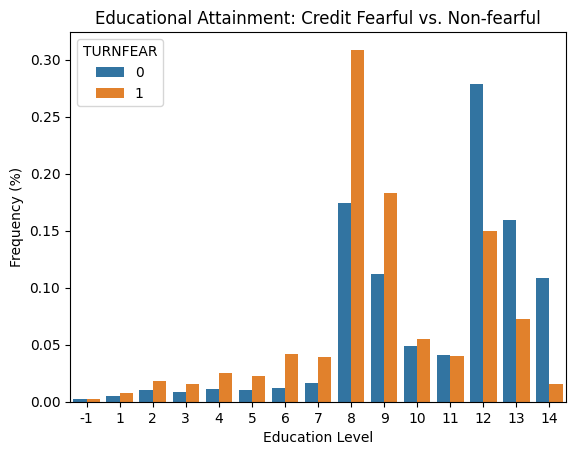

In [33]:
# Create bar chart of `df_educ`
sns.barplot(
    x="EDUC",
    y="Frequency",
    hue="TURNFEAR",
    data=df_educ
)
plt.xlabel("Education Level")
plt.ylabel("Frequency (%)")
plt.title("Educational Attainment: Credit Fearful vs. Non-fearful");

**Interpretation:**

The distribution of educational attainment reveals that credit-fearful respondents are disproportionately concentrated in lower and middle educational categories, while non-fearful respondents are more prevalent among higher educational levels. The findings suggest a negative relationship between educational attainment and credit fear, whereby individuals with greater education appear less likely to avoid applying for credit due to concerns about rejection. This pattern may reflect the role of education in enhancing financial literacy, economic opportunities, and confidence in navigating credit markets.

### Task 2.15: Use df to make a scatter plot showing the relationship between DEBT and ASSET.

- Create a scatter plot with pandas.

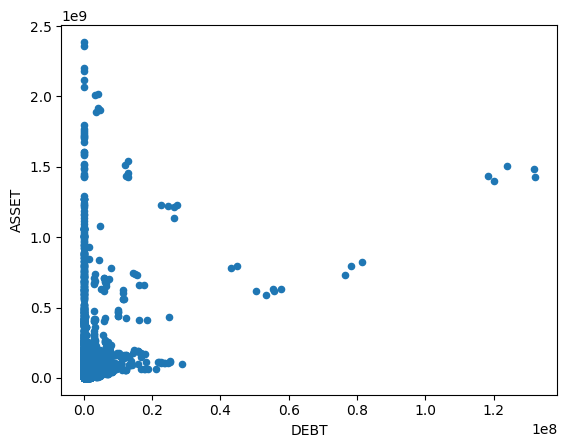

In [34]:
# Create scatter plot of ASSET vs DEBT, df
df.plot.scatter(x="DEBT", y="ASSET");

**Interpretation:**

The scatter plot reveals a positive but relatively weak association between household debt and total assets. While households with larger debt balances generally possess greater asset holdings, considerable dispersion exists across all debt levels. The presence of high-asset households with relatively low debt and high-debt households with substantial wealth suggests that borrowing is frequently used as a wealth accumulation mechanism rather than solely reflecting financial hardship. Overall, the results indicate that debt explains only a limited portion of the variation in household asset holdings, with other socioeconomic factors contributing significantly to wealth accumulation.

### Task 2.16: Use df_fear to make a scatter plot showing the relationship between DEBT and ASSET.

- Create a scatter plot with pandas.

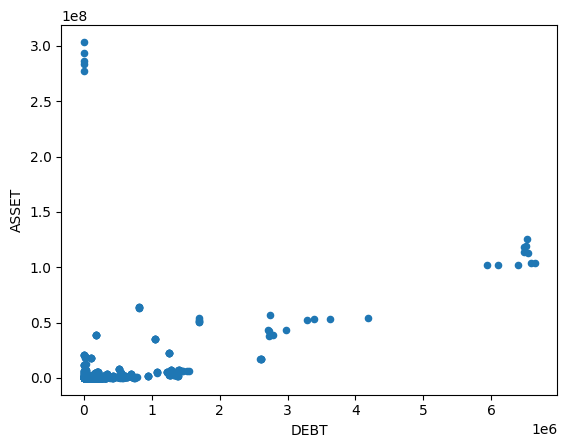

In [35]:
# Create scatter plot of ASSET vs DEBT, df_fear
df_fear.plot.scatter(x="DEBT", y="ASSET");

**Interpretation:**

The scatter plot reveals a moderate positive relationship between debt and total assets among credit-fearful households. While most respondents possess relatively low debt and asset levels, households with larger debt balances generally hold greater wealth, indicating that borrowing is frequently used to finance asset acquisition. The stronger association compared with the overall SCF sample suggests that debt plays a more important role in wealth accumulation for credit-fearful households. Nevertheless, substantial variation in asset holdings at similar debt levels indicates that other factors, including income, homeownership, and investment portfolios, also contribute significantly to household wealth.

### Task 2.17: Use df to make a scatter plot showing the relationship between HOUSES and DEBT.

- Create a scatter plot with pandas.

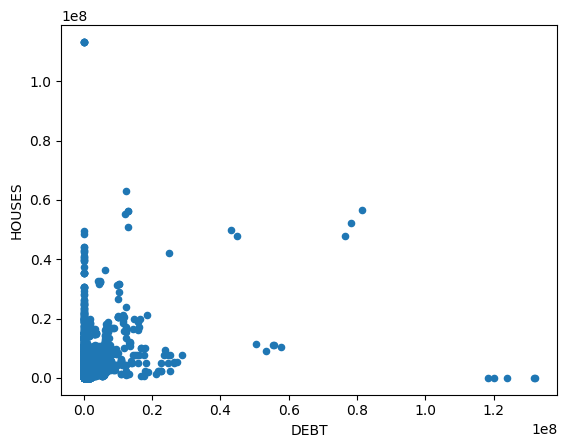

In [36]:
# Create scatter plot of HOUSES vs DEBT, df
df.plot.scatter(x="DEBT", y="HOUSES");

**Interpretation:**

The scatter plot reveals a weak-to-moderate positive relationship between household debt and housing wealth. Although households with more valuable homes generally tend to hold higher levels of debt, considerable variation exists across observations. The pattern is consistent with the widespread use of mortgage financing in housing markets. However, the modest strength of the relationship suggests that debt levels are influenced by factors beyond housing wealth, including business borrowing, consumer credit, and investment-related liabilities. Consequently, housing wealth explains only a limited portion of the variation in household debt within the SCF sample.

### Task 2.18: Use df_fear to make a scatter plot showing the relationship between HOUSES and DEBT.

- Create a scatter plot with pandas.

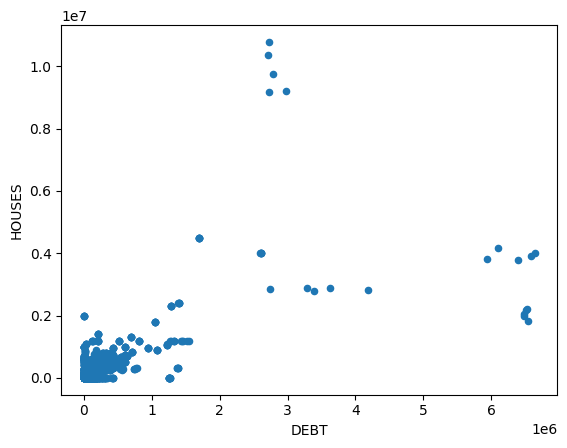

In [37]:
# Create scatter plot of HOUSES vs DEBT, df_fear
df_fear.plot.scatter(x="DEBT", y="HOUSES");

**Integration:**

The scatter plot reveals a strong positive association between debt and housing wealth among credit-fearful households. Although most respondents possess relatively low levels of both debt and housing wealth, households with more valuable homes generally carry larger debt balances. The correlation between housing wealth and debt (r = 0.677) is substantially stronger than that observed in the full SCF sample (r = 0.252), indicating that housing assets among credit-fearful households are more heavily debt-financed. These results suggest that homeownership within this group relies extensively on leverage, potentially increasing financial vulnerability and reinforcing concerns regarding future credit access.
